Remaining Missing Values:
 id          0
age         0
trestbps    0
chol        0
fbs         0
thalch      0
exang       0
oldpeak     0
ca          0
num         0
dtype: int64


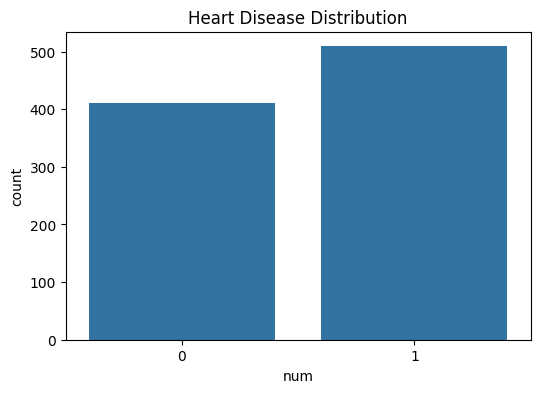


Accuracy: 0.8152173913043478


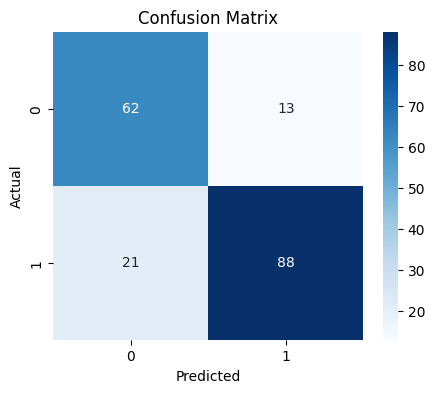

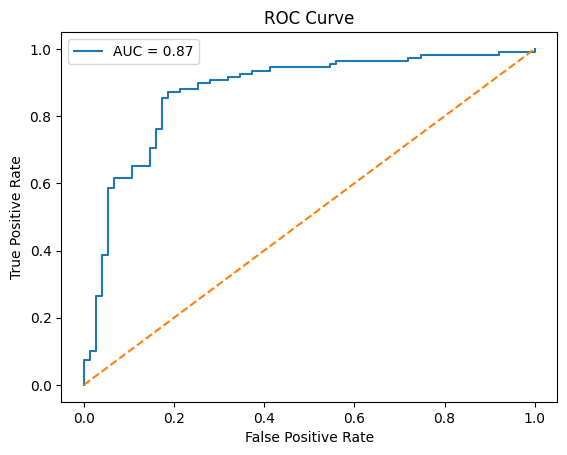

ROC-AUC Score: 0.8740061162079511

Top Important Features:

    Feature  Importance
0        id    0.876700
8        ca    0.873934
7   oldpeak    0.705427
6     exang    0.670081
4       fbs    0.070173
2  trestbps    0.059392
1       age   -0.099800
5    thalch   -0.359380
3      chol   -0.425004


In [6]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score


# 1. Load Dataset
df = pd.read_csv("heart_disease_uci.csv")


# 2. Data Cleaning
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# Convert all columns to numeric safely
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop columns that are completely empty
df.dropna(axis=1, how='all', inplace=True)

# Fill remaining missing values with median
df.fillna(df.median(), inplace=True)

# Drop any rows still containing NaN (safety step)
df.dropna(inplace=True)

print("Remaining Missing Values:\n", df.isnull().sum())


# 3. Identify Target Column
if 'target' in df.columns:
    target_col = 'target'
elif 'num' in df.columns:
    target_col = 'num'
    df[target_col] = df[target_col].apply(lambda x: 1 if x > 0 else 0)
else:
    raise Exception("Target column not found")


# 4. EDA
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("Heart Disease Distribution")
plt.show()

# 5. Prepare Data
X = df.drop(target_col, axis=1)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# 6. Train Model
model = LogisticRegression(max_iter=3000)
model.fit(X_train, y_train)


# 7. Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]


# 8. Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC Score:", auc_score)


# 9. Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
}).sort_values(by='Importance', ascending=False)

print("\nTop Important Features:\n")
print(importance)
